In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
#import mlba
#%matplotlib inline

In [2]:
# 1. Load the dataset
df = pd.read_csv('cf2026-sac.csv')

# remove games with zero score
df = df[(df['winscore'] + df['losescore']) > 0].copy()
df

,date,winner,winscore,loser,losescore
0,2026-09-12,Lenoir-Rhyne,21,Newberry,14
1,2026-09-12,Anderson_SC,39,UVA-Wise,21
2,2026-09-12,Carson-Newman,24,Wingate,23
3,2026-09-12,Tusculum,28,Emory_&_Henry,26
4,2026-09-12,Mars_Hill,22,Catawba,16
5,2026-09-19,Carson-Newman,42,UVA-Wise,7
6,2026-09-19,Anderson_SC,14,Tusculum,7
7,2026-09-19,Newberry,25,Wingate,22
8,2026-09-19,Catawba,24,Emory_&_Henry,10
9,2026-09-19,Mars_Hill,15,Lenoir-Rhyne,7


In [3]:
G = nx.from_pandas_edgelist(df, 'winner', 'loser')
print(G.degree())
nx.density(G)

[('Lenoir-Rhyne          ', 2), ('Newberry              ', 2), ('Anderson_SC           ', 2), ('UVA-Wise              ', 2), ('Carson-Newman         ', 2), ('Wingate               ', 2), ('Tusculum              ', 2), ('Emory_&_Henry         ', 2), ('Mars_Hill             ', 2), ('Catawba               ', 2)]


0.2222222222222222

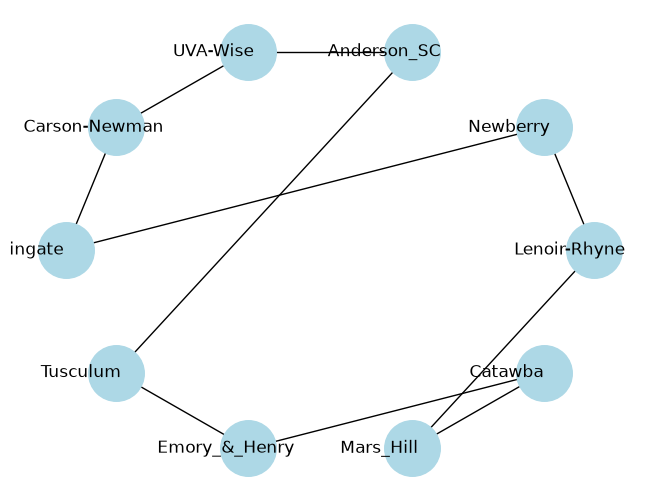

In [4]:
nx.draw_circular(G, with_labels=True, node_color='lightblue', node_size=1600)

plt.show()

In [5]:
G = nx.from_pandas_edgelist(
    df,
    source='winner', 
    target='loser', 
    create_using=nx.DiGraph
)

# 3. Calculate degrees
degree_df = pd.DataFrame({
    'Team': list(G.nodes()),
    'Out-Degree (Losses)': [G.out_degree(node) for node in G.nodes()],
    'In-Degree (Wins)': [G.in_degree(node) for node in G.nodes()]
})

# 4. Add Total Games played and sort by Wins
degree_df['Total Games'] = degree_df['In-Degree (Wins)'] + degree_df['Out-Degree (Losses)']
degree_df = degree_df.sort_values(by=['In-Degree (Wins)', 'Out-Degree (Losses)'], ascending=[False, True]).reset_index(drop=True)

# Display in Jupyter Notebook
degree_df

,Team,Out-Degree (Losses),In-Degree (Wins),Total Games
0,UVA-Wise,0,2,2
1,Wingate,0,2,2
2,Emory_&_Henry,0,2,2
3,Lenoir-Rhyne,1,1,2
4,Newberry,1,1,2
5,Tusculum,1,1,2
6,Catawba,1,1,2
7,Anderson_SC,2,0,2
8,Carson-Newman,2,0,2
9,Mars_Hill,2,0,2


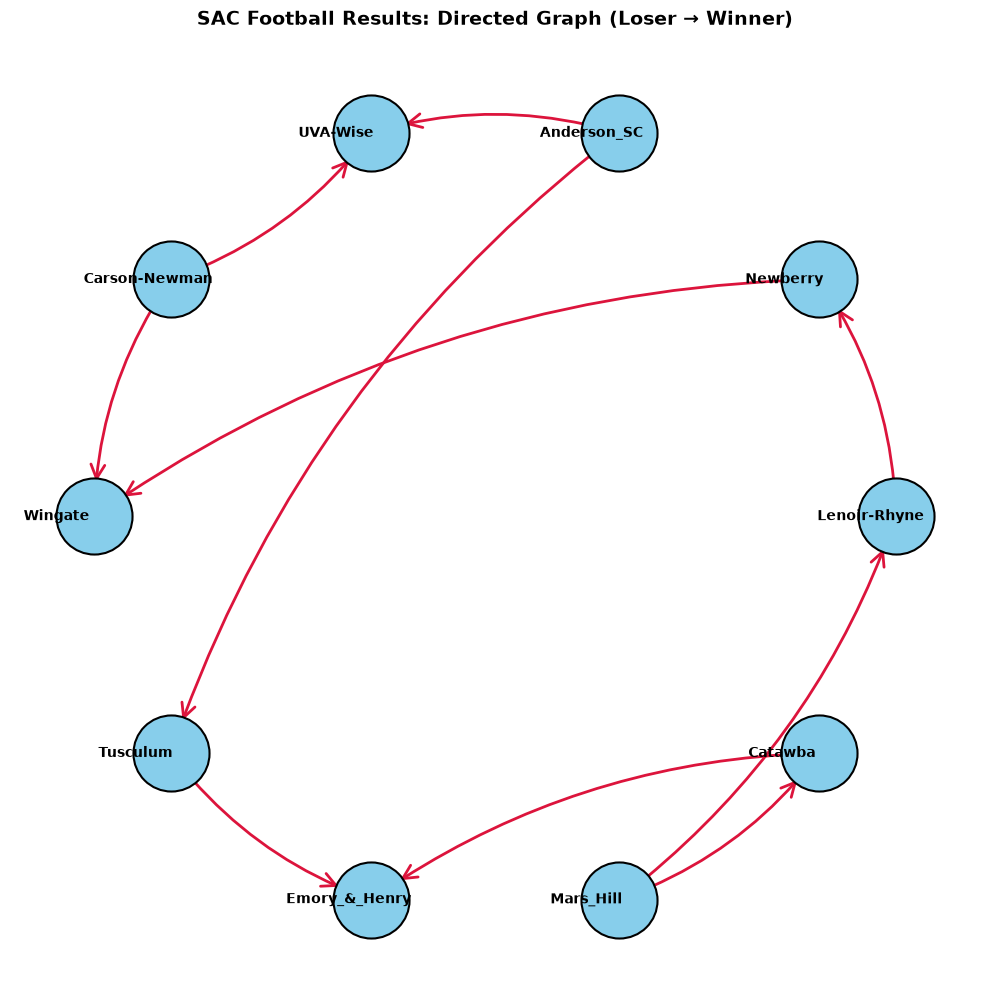

In [6]:
# 3. Setup plot and circular node layout
plt.figure(figsize=(10, 10))
pos = nx.circular_layout(G)

# 4. Draw nodes and team labels
nx.draw_networkx_nodes(G, pos, node_color='#87CEEB', node_size=3000, edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# 5. Draw directed edges with margins so arrowheads are visible outside the nodes
nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowstyle='->',
    arrowsize=25,
    edge_color='crimson',
    width=2,
    connectionstyle='arc3,rad=0.15',
    min_source_margin=25,  # Offsets line start from node center
    min_target_margin=25   # Offsets arrowhead from target node center
)

# 6. Display plot
plt.title("SAC Football Results: Directed Graph (Loser → Winner)", fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# 3. Generate Adjacency Matrix DataFrame
adj_matrix = nx.to_pandas_adjacency(G, dtype=int)

# Display matrix in Jupyter
adj_matrix

,Lenoir-Rhyne,Newberry,Anderson_SC,UVA-Wise,Carson-Newman,Wingate,Tusculum,Emory_&_Henry,Mars_Hill,Catawba
Lenoir-Rhyne,0,1,0,0,0,0,0,0,0,0
Newberry,0,0,0,0,0,1,0,0,0,0
Anderson_SC,0,0,0,1,0,0,1,0,0,0
UVA-Wise,0,0,0,0,0,0,0,0,0,0
Carson-Newman,0,0,0,1,0,1,0,0,0,0
Wingate,0,0,0,0,0,0,0,0,0,0
Tusculum,0,0,0,0,0,0,0,1,0,0
Emory_&_Henry,0,0,0,0,0,0,0,0,0,0
Mars_Hill,1,0,0,0,0,0,0,0,0,1
Catawba,0,0,0,0,0,0,0,1,0,0
